In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mticker

In [2]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["order_date", "ship_date"]
)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,day_name,week,day,shipping_days,sales_per_unit,profit_per_unit,discount_amount,profit_status,profit_margin,order_value
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Tuesday,45,8,3,130.9800,20.9568,0.000000,Profit,16.00,261.9600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Tuesday,45,8,3,243.9800,73.1940,0.000000,Profit,30.00,731.9400
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Sunday,23,12,4,7.3100,3.4357,0.000000,Profit,47.00,14.6200
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Sunday,41,11,7,191.5155,-76.6062,430.909875,Loss,-40.00,957.5775
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Sunday,41,11,7,11.1840,1.2582,4.473600,Profit,11.25,22.3680


# 1. Which region generated the highest sales?

In [3]:
sales_by_region  = (df.groupby("region")["sales"].sum().sort_values(ascending=False).reset_index())
sales_by_region 

,region,sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


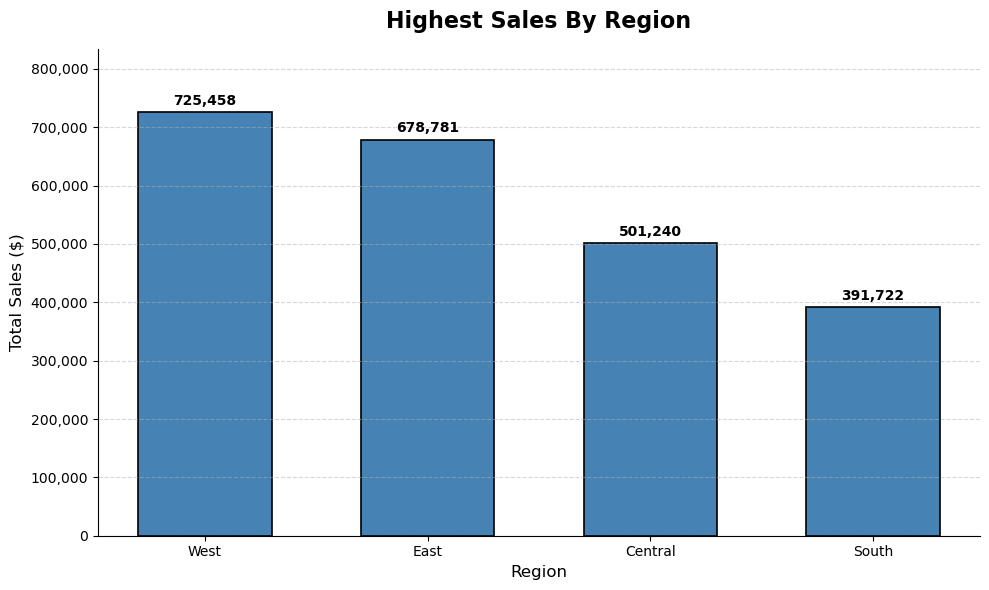

In [4]:
plt.figure(figsize=(10,6))

bars = plt.bar(sales_by_region ["region"], sales_by_region ["sales"],
        color="steelblue", edgecolor="black", linewidth=1.2, width=0.6

)

plt.title("Highest Sales By Region", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0, sales_by_region ["sales"].max() * 1.15)

# format y-axis values
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

offset = sales_by_region ["sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f"{bar.get_height():,.0f}",
        va="bottom", ha="center", fontweight="bold", fontsize=10
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/sales_by_region.png", dpi=300, bbox_inches="tight"
)

plt.show()

## Insight
- One region generated the highest total sales.
- This region is the strongest market for the company.
- The company should continue investing in this region.

# 2. Which region generated the highest profit?

In [5]:
profit_by_region  = (df.groupby("region")["profit"].sum().sort_values(ascending=False).reset_index())
profit_by_region 

,region,profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


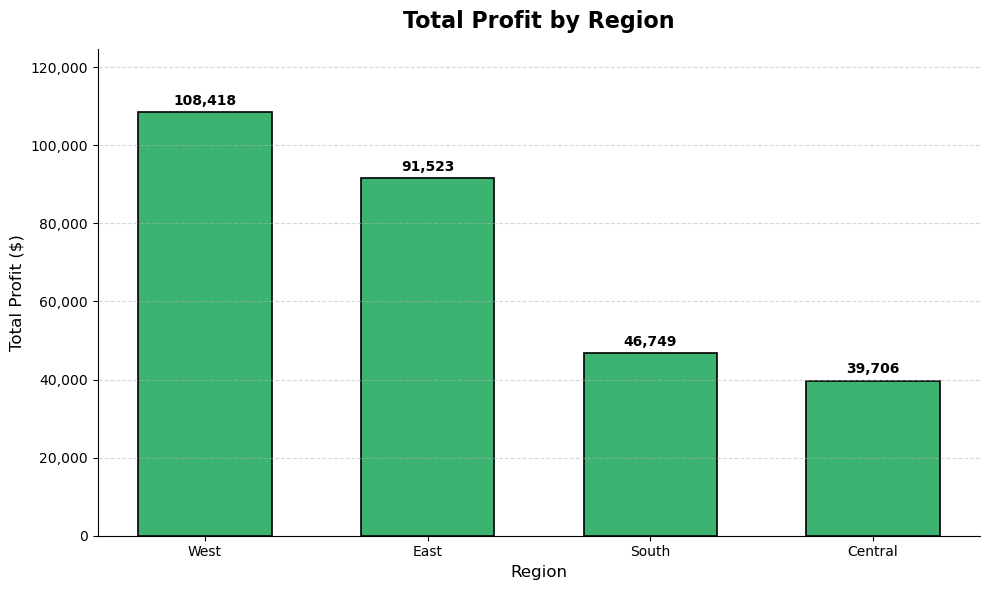

In [6]:
plt.figure(figsize=(10,6))

bars = plt.bar(profit_by_region["region"], profit_by_region["profit"],
        color="mediumseagreen", edgecolor="black", linewidth=1.2, width=0.6

)

plt.title("Total Profit by Region", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0, profit_by_region["profit"].max() * 1.15)

# format y-axis values
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

offset = profit_by_region["profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f"{bar.get_height():,.0f}",
        va="bottom", ha="center", fontweight="bold", fontsize=10
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/profit_by_region.png", dpi=300, bbox_inches="tight"
)

plt.show()

## Insight
- Profit is not the same across all regions.
- One region contributes the highest profit.
- The company should focus on maintaining profitability in this region.

# 3. Which region generated the highest losses?

In [7]:
region_loss = (
    df.groupby("region")["profit"]
      .sum()
      .sort_values(ascending=True)   # Most negative profit first
      .reset_index()
)

region_loss



,region,profit
0,Central,39706.3625
1,South,46749.4303
2,East,91522.7800
3,West,108418.4489


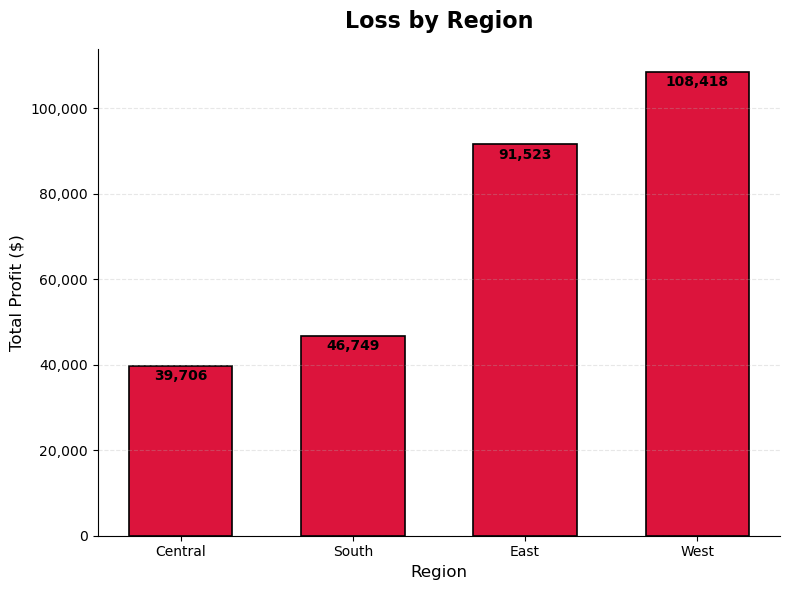

In [8]:

plt.figure(figsize=(8,6))

bars = plt.bar(
    region_loss["region"],
    region_loss["profit"],
    color="crimson",
    edgecolor="black",
    linewidth=1.2,
    width=0.6
)

plt.title(
    "Loss by Region",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Format Y-axis
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

# Value Labels
offset = abs(region_loss["profit"].min()) * 0.02

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - offset,
        f"{bar.get_height():,.0f}",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

# Remove Top & Right Border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/region_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight
- Some regions generated lower profit or losses.
- High discounts or operational costs may be reducing profit.
- These regions should be analyzed to improve profitability.

# 4. Which states generated the highest sales? (Top 10)


In [9]:
top10_sales_by_states = (df.groupby("state")["sales"].sum().sort_values(ascending=False).head(10).reset_index())
top10_sales_by_states

,state,sales
0,California,457687.6315
1,New York,310876.2710
2,Texas,170188.0458
3,Washington,138641.2700
4,Pennsylvania,116511.9140
5,Florida,89473.7080
6,Illinois,80166.1010
7,Ohio,78258.1360
8,Michigan,76269.6140
9,Virginia,70636.7200


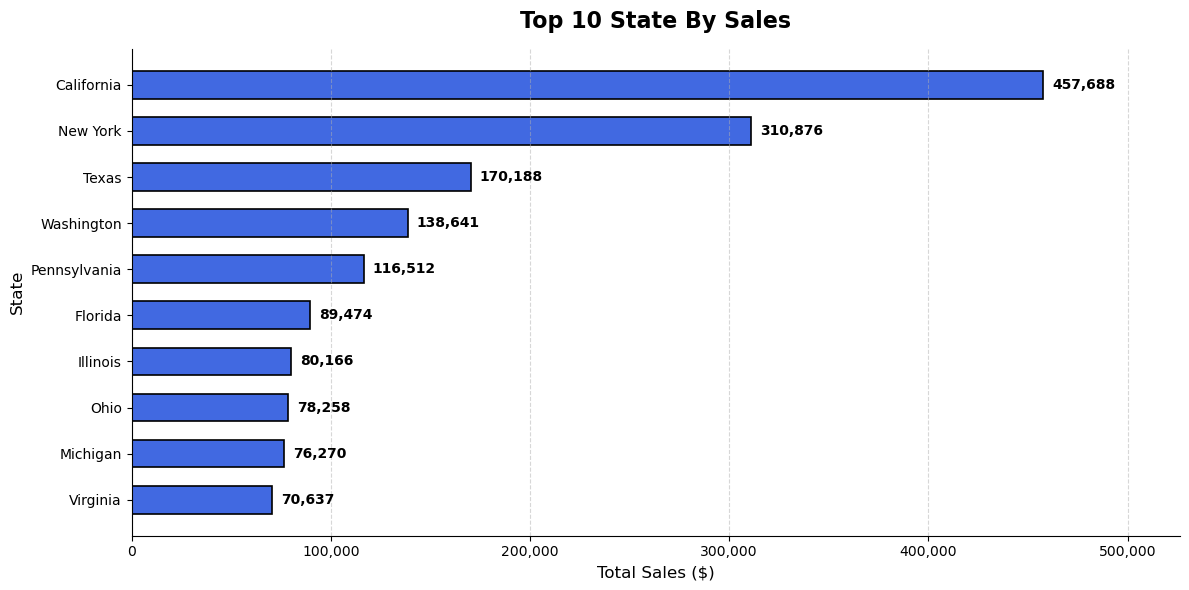

In [10]:
plt.figure(figsize=(12,6))

bars = plt.barh(top10_sales_by_states["state"], top10_sales_by_states["sales"],
        color="#4169E1", edgecolor="black", linewidth=1.2, height=0.6

)

plt.gca().invert_yaxis()

plt.title("Top 10 State By Sales", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Sales ($)", fontsize=12)

plt.ylabel("State", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0, top10_sales_by_states["sales"].max() * 1.15)

# format y-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

offset = top10_sales_by_states["sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left", fontweight="bold", fontsize=10
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/sales_by_states.png", dpi=300, bbox_inches="tight"
)

plt.show()

## Insight
- A few states contribute a large share of total sales.
- These states are the company's key markets.
- Sales strategies can be strengthened in these locations.

# 5. Which states generated the highest profit? (Top 10)

In [11]:
top10_profit_by_states = (df.groupby("state")["profit"].sum().sort_values(ascending=False).head(10).reset_index())
top10_profit_by_states

,state,profit
0,California,76381.3871
1,New York,74038.5486
2,Washington,33402.6517
3,Michigan,24463.1876
4,Virginia,18597.9504
5,Indiana,18382.9363
6,Georgia,16250.0433
7,Kentucky,11199.6966
8,Minnesota,10823.1874
9,Delaware,9977.3748


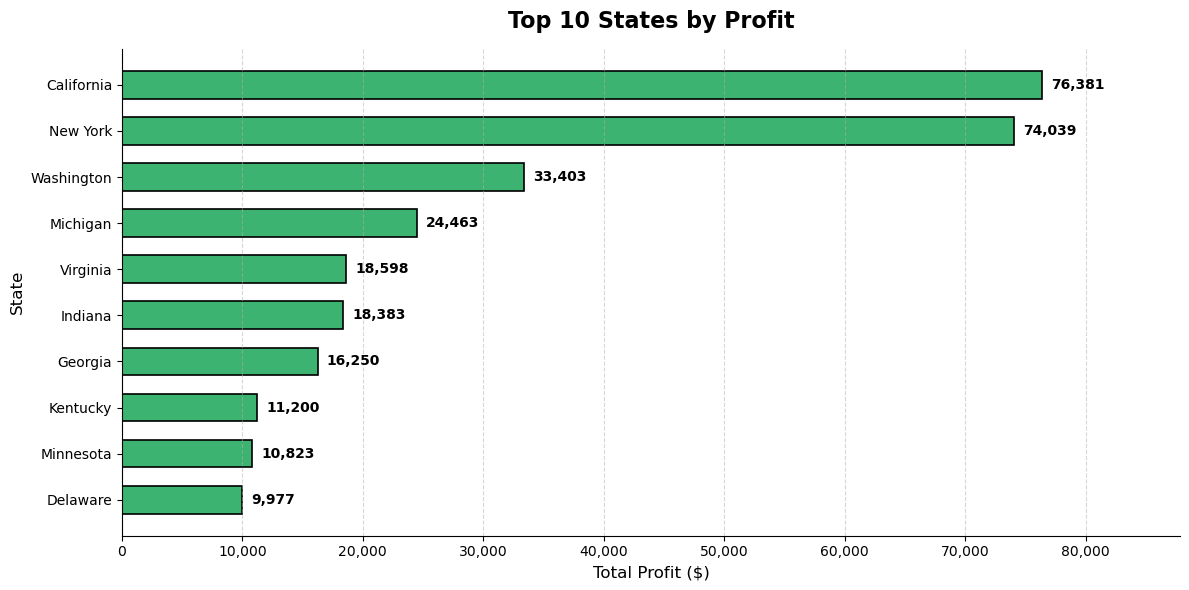

In [12]:
plt.figure(figsize=(12,6))

bars = plt.barh(top10_profit_by_states["state"], top10_profit_by_states["profit"],
        color="mediumseagreen", edgecolor="black", linewidth=1.2, height=0.6

)

plt.gca().invert_yaxis()

plt.title("Top 10 States by Profit", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit ($)", fontsize=12)

plt.ylabel("State", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0, top10_profit_by_states["profit"].max() * 1.15)

# format y-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

offset = top10_profit_by_states["profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left", fontweight="bold", fontsize=10
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/profit_by_states.png", dpi=300, bbox_inches="tight"
)

plt.show()

## Insight
- The most profitable states are not always the highest sales states.
- These states provide better business returns.
- The company should protect and expand these profitable markets.

# 6. Which states generated the highest losses? 

In [13]:
top10_loss_by_states = (df.groupby("state")["profit"].sum().sort_values(ascending=True).head(10).reset_index())
top10_loss_by_states

,state,profit
0,Texas,-25729.3563
1,Ohio,-16971.3766
2,Pennsylvania,-15559.9603
3,Illinois,-12607.8870
4,North Carolina,-7490.9122
5,Colorado,-6527.8579
6,Tennessee,-5341.6936
7,Arizona,-3427.9246
8,Florida,-3399.3017
9,Oregon,-1190.4705


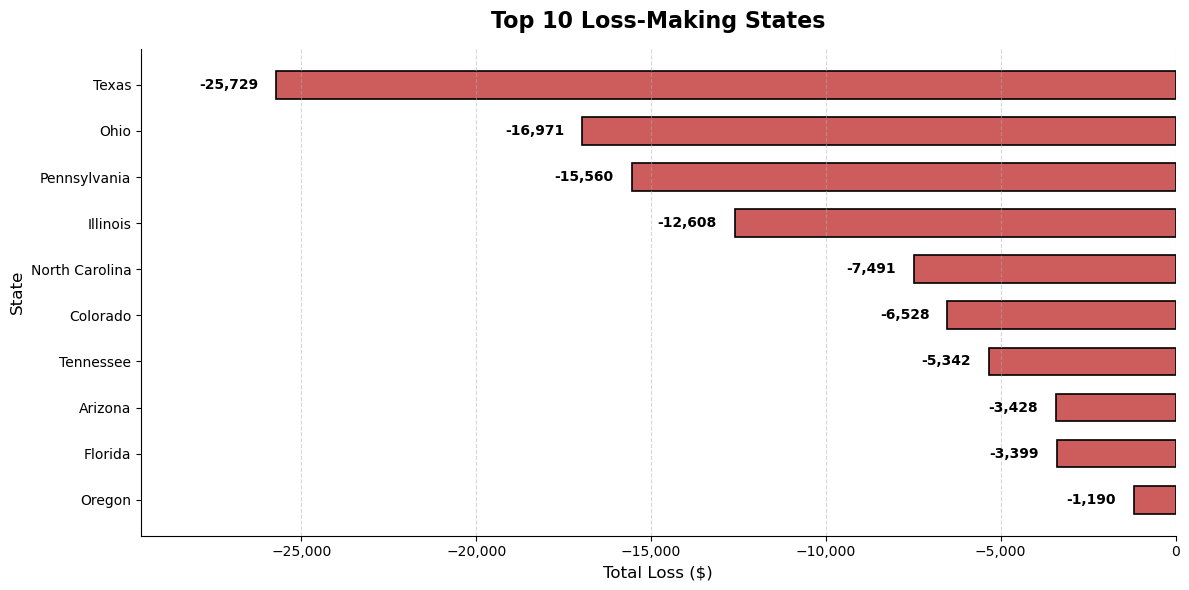

In [14]:

plt.figure(figsize=(12,6))

bars = plt.barh(
    top10_loss_by_states["state"],
    top10_loss_by_states["profit"],
    color="indianred",
    edgecolor="black",
    linewidth=1.2,
    height=0.6
)

# Highest loss at top
plt.gca().invert_yaxis()

plt.title(
    "Top 10 Loss-Making States",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total Loss ($)", fontsize=12)
plt.ylabel("State", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Format X-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

plt.xlim(top10_loss_by_states["profit"].min()*1.15, 0)

offset = abs(top10_loss_by_states["profit"].min()) * 0.02

# Value Labels
for bar in bars:
    plt.text(
        bar.get_width() - offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="right",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/top10_loss_by_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Some states generated significant losses.
- High discounts, shipping costs, or low-margin products may be responsible.
- These states require business improvement strategies.

# 7. What is the distribution of regional sales?

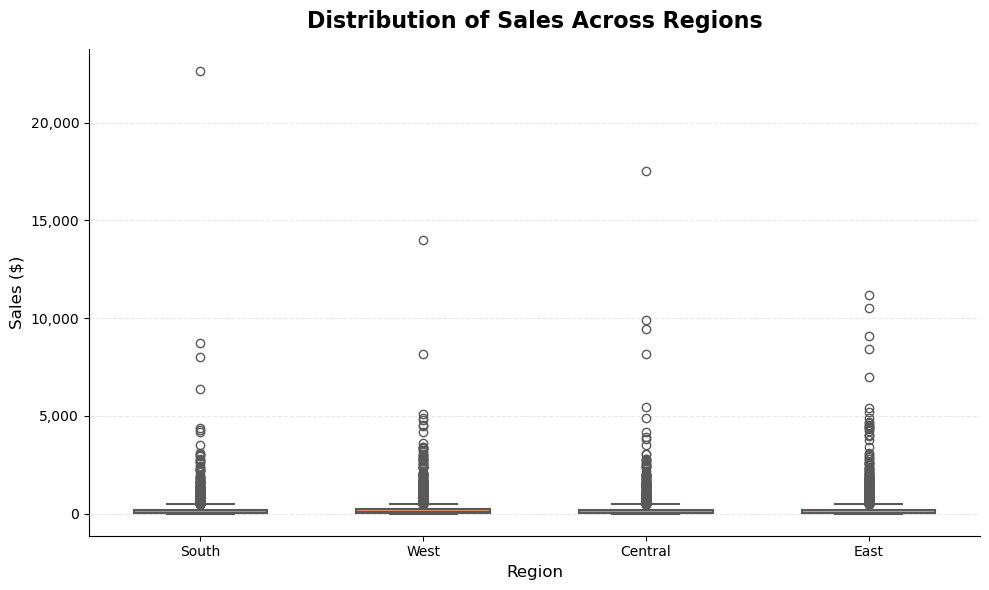

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="region",
    y="sales",
    hue="region",
    palette="Set2",
    linewidth=1.5,
    width=0.6
)

plt.title(
    "Distribution of Sales Across Regions",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Region", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Format Y-axis
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

# Remove Top & Right Border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/region_sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Insight
- Sales vary across different regions.
- Some regions have a wider spread of sales than others.
- Outliers indicate a few very large sales orders.

# 8. What is the relationship between sales and profit across regions?

In [18]:

region_sales_profit = (
    df.groupby("region")[["sales", "profit"]]
      .sum()
      .reset_index()
)

region_sales_profit

,region,sales,profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


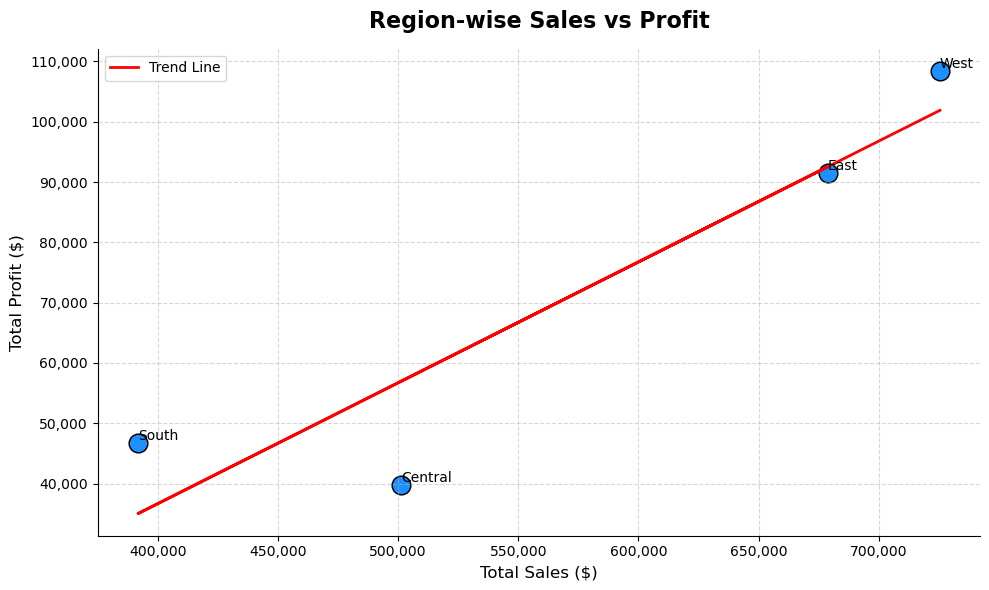

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=region_sales_profit,
    x="sales",
    y="profit",
    s=180,
    color="dodgerblue",
    edgecolor="black"
)

# Region Labels

for i in range(len(region_sales_profit)):
    plt.text(
        region_sales_profit["sales"][i],
        region_sales_profit["profit"][i],
        region_sales_profit["region"][i],
        fontsize=10,
        ha="left",
        va="bottom"
        
    )
    
# Trend Line 
z = np.polyfit(
    region_sales_profit["sales"],
    region_sales_profit["profit"],
    1
)

p = np.poly1d(z)

plt.plot(
    region_sales_profit["sales"],
    p(region_sales_profit["sales"]),
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title(
    "Region-wise Sales vs Profit",
    fontsize=16,
    fontweight="bold", 
    pad=15
)

plt.xlabel("Total Sales ($)", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

# Format Axes
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.legend()

plt.gca().spines["top"].set_visible(False)

plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/region/region_sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Higher sales do not always result in higher profit.
- Some regions achieve high sales but lower profit margins.
- Profitability depends on more than just sales volume.